## 13.6. Object Detection Datasets

### 13.6.1 Download Dataset

In [1]:
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

#@save
d2l.DATA_HUB['banana-detection'] = (
  d2l.DATA_URL + 'banana-detection.zip', '5de26c8fce5ccdea9f91267273464dc968d20d72'
)

### 13.6.2 Read Dataset

In [2]:
#@save
def read_data_bananas(is_train=True):
  """read image and labels in banana detect dataset"""
  data_dir = d2l.download_extract('banana-detection')
  csv_fname = os.path.join(data_dir, 'bananas_train' if is_train else 'bananas_val', 'label.csv') 
  csv_data = pd.read_csv(csv_fname)
  csv_data = csv_data.set_index('img_name')
  images, targets = [], []
  for img_name, target in csv_data.iterrows():
    images.append(torchvision.io.read_image(
      os.path.join(data_dir, 'bananas_train' if is_train else 'bananas_val', 'images', f'{img_name}')
    ))
    # 这里的target包含（类别，左上角x，左上角y，右下角x，右下角y），
    # 其中所有图像都具有相同的香蕉类（索引为0）
    targets.append(list(target))
  return images, torch.tensor(targets).unsqueeze(1) / 256

In [3]:
#@save
import torch.utils
import torch.utils.data


class BananasDataset(torch.utils.data.Dataset):
  """a self-defined dataset for loading banana detection"""
  def __init__(self, is_train):
    self.features, self.labels = read_data_bananas(is_train)
    print('read' + str(len(self.features)) + (f' training examples' if is_train else f' validation examples'))
  
  def __getitem__(self, idx):
    return (self.features[idx].float(), self.labels[idx])
  
  def __len__(self):
    return len(self.features)  

In [4]:
#@save
def load_data_bananas(batch_size):
  """load banana detection dataset"""
  train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True), batch_size, shuffle=True)
  val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False), batch_size)
  return train_iter, val_iter

In [5]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

read1000 training examples
read100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

### 13.6.3 Demostration

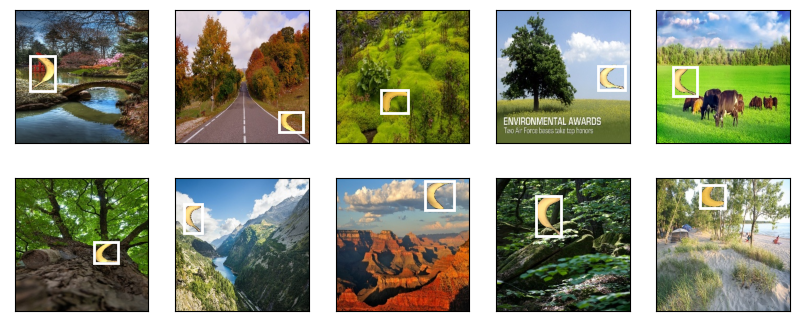

In [6]:
imgs = (batch[0][0:10].permute(0, 2, 3, 1)) / 255
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]):
  d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w'])